In [1]:
#ここではscikit-learnのlinear regressionを実装していくで
#サンプルデータとしては有名なボストン住宅価格を用いるで

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import load_boston
boston = load_boston()

df = pd.DataFrame(boston.data)
df

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48


In [19]:
df.columns = boston.feature_names
df["MEDV"] = boston.target
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48,22.0


In [20]:
#まずは平均部屋数(RM)と価格(MEDV)を単回帰分析

In [32]:
#欠損値の確認
df["RM"].isnull().sum()

0

In [33]:
df["MEDV"].isnull().sum()

0

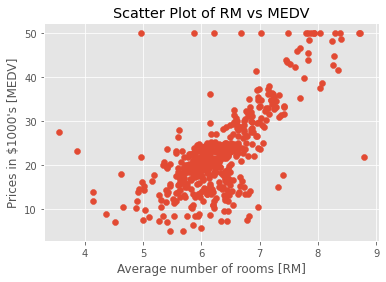

In [26]:
plt.scatter(df["RM"], df["MEDV"])
plt.title("Scatter Plot of RM vs MEDV")
plt.xlabel('Average number of rooms [RM]')
plt.ylabel('Prices in $1000\'s [MEDV]')
plt.show()

In [17]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

X = df[["RM"]].values
y = df["MEDV"].values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.7, test_size = 0.3, random_state = 0)

lr.fit(X_train, y_train)

LinearRegression()

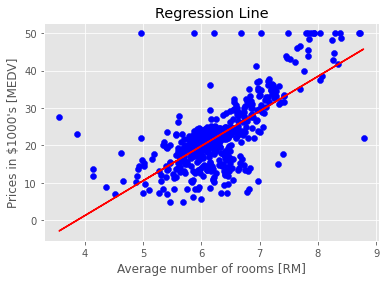

In [39]:
plt.scatter(X, y, color = 'blue')         
plt.plot(X_train, lr.predict(X_train), color = 'red') 

plt.title('Regression Line')               
plt.xlabel('Average number of rooms [RM]')
plt.ylabel('Prices in $1000\'s [MEDV]')    

plt.show()

In [40]:
#回帰モデルを評価

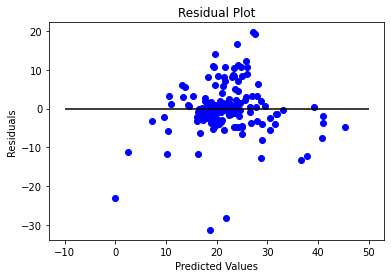

In [20]:
y_pred = lr.predict(X_test)

plt.scatter(y_pred, y_pred - y_test, color = 'blue')      
plt.hlines(y = 0, xmin = -10, xmax = 50, color = 'black') 
plt.title('Residual Plot')                                
plt.xlabel('Predicted Values')                            
plt.ylabel('Residuals')                                   

plt.show()    

In [21]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

y_train_pred = lr.predict(X_train)

print('MSE train data: ', mean_squared_error(y_train, y_train_pred))
print('MSE test data: ', mean_squared_error(y_test, y_pred))
print('r^2 train data: ', r2_score(y_train, y_train_pred))
print('r^2 test data: ', r2_score(y_test, y_pred))

MSE train data:  42.15765086312224
MSE test data:  47.03304747975519
r^2 train data:  0.5026497630040827
r^2 test data:  0.4351436483211518


In [43]:
#全然あかんやん

In [44]:
#ここから重回帰分析
#グラフ化は省略

In [24]:
X2 = df.drop("MEDV", axis=1)
y2 = df["MEDV"]

In [25]:
lr2 = LinearRegression()

from sklearn.model_selection import train_test_split
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, train_size = 0.7, test_size = 0.3, random_state = 0)

lr2.fit(X2_train, y2_train)

LinearRegression()

In [29]:
y2_pred = lr2.predict(X2_test)
y2_train_pred = lr2.predict(X2_train)

print('MSE train data: ', mean_squared_error(y2_train, y2_train_pred))
print('MSE test data: ', mean_squared_error(y2_test, y2_pred))
print('r^2 train data: ', r2_score(y2_train, y2_train_pred))
print('r^2 test data: ', r2_score(y2_test, y2_pred))

MSE train data:  19.958219814238046
MSE test data:  27.195965766883422
r^2 train data:  0.7645451026942549
r^2 test data:  0.673382550640017
